# SKlearn GPR - test

In [1]:
import numpy as np 
import matplotlib.pyplot as plt

from gpder import plot_gpr

from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.metrics import mean_squared_error

### Noisy sine function

In [2]:
def F(X, s=0):
    # X: query points to evaluate the function on 
    # s: noise level
    return np.sin(X) + s * np.random.uniform(-1, 1, X.shape[0])

def dF(X):
    # X: query points to evaluate the function on 
    return np.cos(X)

In [3]:
np.random.seed(123)

# training data 
X_train = np.array([-4, -3.5, 0, -2.3, 1, 3.1], dtype=float)
y_train = F(X_train, s=0.1) 
dX_train = X_train
dy_train = dF(dX_train)

# data to predict
X_star = np.linspace(-5, 5, 100)

# true function
y_star = F(X_star)

### Regular GPR

In [4]:
kernel = ConstantKernel(1) * RBF(1) + WhiteKernel(1)

1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1)


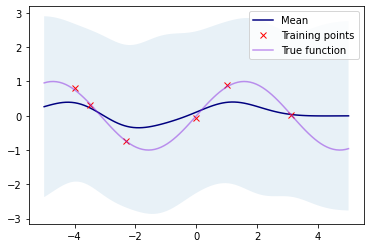

LML :  -7.961597832393251
MSE :  0.28603100575389145


In [5]:
np.random.seed(123)

gpr = GaussianProcessRegressor(kernel=kernel, 
                               optimizer=None,
                               #n_restarts_optimizer=10,
                               random_state=1)
gpr.fit(X_train.reshape(-1, 1), y_train)
       
print(kernel)

mu, std = gpr.predict(X_star.reshape(-1, 1), return_std=True)
mu, cov = gpr.predict(X_star.reshape(-1, 1), return_cov=True)
mu = mu.ravel()

samples = np.random.multivariate_normal(mu, cov, 6)
samples = []

plot_gpr(X_train=X_train, y_train=y_train, dX_train=[], dy_train=[],
         X_star=X_star, mu_star=mu, std_star=std, samples=samples,
         F=F)

lml = gpr.log_marginal_likelihood_value_
print("LML : ", lml)

mean_err = mean_squared_error(y_star, mu)
print("MSE : ", mean_err)

1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1)


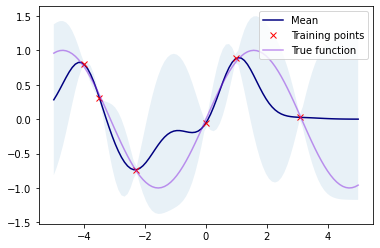

LML :  -4.992240582358212
MSE :  0.2221925480500659


In [6]:
np.random.seed(123)

gpr = GaussianProcessRegressor(kernel=kernel, 
                               #optimizer=None,
                               n_restarts_optimizer=10,
                               random_state=1)
gpr.fit(X_train.reshape(-1, 1), y_train)
       
print(kernel)

mu, std = gpr.predict(X_star.reshape(-1, 1), return_std=True)
mu, cov = gpr.predict(X_star.reshape(-1, 1), return_cov=True)
mu = mu.ravel()

samples = np.random.multivariate_normal(mu, cov, 6)
samples = []

plot_gpr(X_train=X_train, y_train=y_train, dX_train=[], dy_train=[],
         X_star=X_star, mu_star=mu, std_star=std, samples=samples,
         F=F)

lml = gpr.log_marginal_likelihood_value_
print("LML : ", lml)

mean_err = mean_squared_error(y_star, mu)
print("MSE : ", mean_err)